# 02 — Entrenamiento Final del Modelo Ganador

Este notebook toma la decisión del `01_eda_model_selection.ipynb`, entrena el modelo ganador con optimización, valida el resultado final y exporta artefactos para backend/producción.

## 1. Configuración

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

ROOT = Path.cwd()
if not (ROOT / 'data' / 'houses_Madrid.csv').exists():
    ROOT = Path.cwd().parents[1]

DATA_PATH = ROOT / 'data' / 'houses_Madrid.csv'
ARTIFACTS_DIR = ROOT / 'model' / 'artifacts'
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TARGET = 'buy_price'

# Features que el formulario pedirá al usuario (16 variables) — debe coincidir exactamente con notebook 01
BASE_FEATURES = [
    'sq_mt_built', 'sq_mt_useful', 'n_rooms', 'n_bathrooms', 'floor',
    'subtitle', 'has_lift', 'has_ac', 'has_parking', 'built_year',
    'is_new_development', 'house_type_id', 'is_renewal_needed',
    'is_exterior', 'has_terrace', 'has_balcony',
]

BOOL_FEATURES = [
    'has_lift', 'has_ac', 'has_parking', 'is_new_development',
    'is_renewal_needed', 'is_exterior', 'has_terrace', 'has_balcony',
]

CAT_FEATURES = ['subtitle', 'house_type_id', 'floor']

MISSING_FLAG_FEATURES = [
    'sq_mt_built', 'sq_mt_useful', 'n_bathrooms', 'floor', 'has_lift',
    'has_ac', 'built_year', 'is_new_development', 'house_type_id',
]

def to_bool_number(value):
    if pd.isna(value):
        return np.nan
    if value is True or value == 'True' or value == 'true' or value == 1:
        return 1.0
    if value is False or value == 'False' or value == 'false' or value == 0:
        return 0.0
    return np.nan

def load_and_prepare(data_path=DATA_PATH):
    raw = pd.read_csv(data_path)
    df = raw[(raw['operation'] == 'sale') & (raw['is_buy_price_known'] == True)].copy()
    df = df.dropna(subset=[TARGET])
    df = df[df[TARGET] > 0].copy()

    original_rows = len(df)
    lower = df[TARGET].quantile(0.005)
    upper = df[TARGET].quantile(0.995)
    df = df[(df[TARGET] >= lower) & (df[TARGET] <= upper)].copy()
    df['subtitle'] = df['subtitle'].astype('string').str.split(',').str[0].fillna('missing')

    model_df = df[BASE_FEATURES + [TARGET]].copy()
    for col in MISSING_FLAG_FEATURES:
        model_df[f'{col}_missing'] = model_df[col].isna().astype(int)
    for col in BOOL_FEATURES:
        model_df[col] = model_df[col].map(to_bool_number)
    for col in CAT_FEATURES:
        model_df[col] = model_df[col].fillna('missing').astype(str)

    features = BASE_FEATURES + [f'{col}_missing' for col in MISSING_FLAG_FEATURES]
    metadata = {
        'raw_rows': int(len(raw)),
        'sale_rows_with_price': int(original_rows),
        'training_rows': int(len(df)),
        'removed_outlier_rows': int(original_rows - len(df)),
        'min_price': round(float(lower), 2),
        'max_price': round(float(upper), 2),
        'features': features,
    }
    return raw, df, model_df[features], model_df[TARGET], metadata

def price_strata(y, q=10):
    return pd.qcut(y, q=q, duplicates='drop', labels=False)

def metric_block(y_true, y_pred):
    from sklearn.metrics import mean_absolute_error, median_absolute_error, r2_score, root_mean_squared_error
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    abs_err = np.abs(y_true - y_pred)
    pct_err = abs_err / y_true
    return {
        'n': int(len(y_true)),
        'RMSE': round(float(root_mean_squared_error(y_true, y_pred)), 2),
        'MAE': round(float(mean_absolute_error(y_true, y_pred)), 2),
        'MedAE': round(float(median_absolute_error(y_true, y_pred)), 2),
        'R2': round(float(r2_score(y_true, y_pred)), 4),
        'MAPE': round(float(pct_err.mean()), 4),
        'MdAPE': round(float(np.median(pct_err)), 4),
        '<=10%': round(float((pct_err <= 0.10).mean()), 4),
        '<=20%': round(float((pct_err <= 0.20).mean()), 4),
        '<=30%': round(float((pct_err <= 0.30).mean()), 4),
        'AE_p90': round(float(np.quantile(abs_err, 0.90)), 2),
        'AE_p95': round(float(np.quantile(abs_err, 0.95)), 2),
        'Bias': round(float(np.mean(y_pred - y_true)), 2),
    }

In [2]:

selection_path = ARTIFACTS_DIR / 'model_selection_summary.json'
if selection_path.exists():
    with open(selection_path, encoding='utf-8') as f:
        selection_summary = json.load(f)
    MODELO_GANADOR = selection_summary['winner']
else:
    MODELO_GANADOR = 'CatBoost'
    print('No existe model_selection_summary.json; usando CatBoost por defecto.')

print('Modelo a entrenar:', MODELO_GANADOR)


Modelo a entrenar: CatBoost


## 2. Carga y split final

In [3]:

raw, df_clean, X, y, data_meta = load_and_prepare()
y_log = np.log1p(y)

from sklearn.model_selection import train_test_split

X_trainval, X_test, y_trainval, y_test, y_log_trainval, y_log_test = train_test_split(
    X, y, y_log, test_size=0.20, random_state=RANDOM_STATE, stratify=price_strata(y)
)
X_train, X_val, y_train, y_val, y_log_train, y_log_val = train_test_split(
    X_trainval, y_trainval, y_log_trainval,
    test_size=0.10, random_state=RANDOM_STATE, stratify=price_strata(y_trainval)
)

print('Train:', X_train.shape, 'Validation:', X_val.shape, 'Test:', X_test.shape)
print('Rango precio:', f"{data_meta['min_price']:,.0f} € - {data_meta['max_price']:,.0f} €")


Train: (15509, 25) Validation: (1724, 25) Test: (4309, 25)
Rango precio: 80,000 € - 4,500,000 €


## 3. Entrenamiento del ganador

Si el ganador no es CatBoost, se entrena con el mismo target logarítmico y un preprocesado compatible. En la práctica esperamos CatBoost porque maneja categorías y nulos mejor en este dataset.

In [4]:

import time
from sklearn.model_selection import RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

NUM_FEATURES = [c for c in X.columns if c not in CAT_FEATURES]
encoded_preprocess = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), NUM_FEATURES),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
        ]), CAT_FEATURES),
    ]
)

def neg_price_mape_scorer(estimator, X_eval, y_log_eval):
    y_true = np.expm1(y_log_eval)
    y_pred = np.expm1(estimator.predict(X_eval)).clip(min=0)
    return -mean_absolute_percentage_error(y_true, y_pred)

if MODELO_GANADOR == 'CatBoost':
    base_model = CatBoostRegressor(
        loss_function='RMSE', eval_metric='RMSE', iterations=900,
        random_state=RANDOM_STATE, verbose=0, allow_writing_files=False
    )
    param_dist = {
        'depth': [4, 6, 8, 10],
        'learning_rate': [0.025, 0.05, 0.075, 0.1],
        'l2_leaf_reg': [1, 3, 5, 10, 20],
        'random_strength': [0.5, 1, 2, 5],
        'bagging_temperature': [0, 0.25, 0.5, 1],
    }
    search = RandomizedSearchCV(
        base_model, param_dist, n_iter=35, cv=3,
        scoring=neg_price_mape_scorer,
        random_state=RANDOM_STATE, n_jobs=1
    )
    t0 = time.time()
    search.fit(X_train, y_log_train, cat_features=CAT_FEATURES)
    best_params = search.best_params_
    print('Mejores parámetros:', best_params)
    print('CV price MAPE:', -search.best_score_)
    print('Tiempo búsqueda:', round(time.time() - t0, 1), 's')

    model_core = CatBoostRegressor(
        **best_params, loss_function='RMSE', eval_metric='RMSE', iterations=2500,
        early_stopping_rounds=100, random_state=RANDOM_STATE,
        cat_features=CAT_FEATURES, allow_writing_files=False
    )
    model_core.fit(X_train, y_log_train, eval_set=(X_val, y_log_val), verbose=100)
    fitted_model_for_importance = model_core
else:
    if MODELO_GANADOR == 'LightGBM':
        base_reg = LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
        param_dist = {
            'model__n_estimators': [500, 800, 1100, 1400],
            'model__learning_rate': [0.025, 0.04, 0.06, 0.08],
            'model__num_leaves': [31, 63, 95, 127],
            'model__min_child_samples': [10, 20, 40, 70],
            'model__subsample': [0.75, 0.9, 1.0],
            'model__colsample_bytree': [0.75, 0.9, 1.0],
            'model__reg_lambda': [0, 1, 3, 8],
        }
    elif MODELO_GANADOR == 'XGBoost':
        base_reg = XGBRegressor(objective='reg:squarederror', random_state=RANDOM_STATE, n_jobs=-1)
        param_dist = {
            'model__n_estimators': [500, 800, 1100],
            'model__max_depth': [3, 4, 5, 6],
            'model__learning_rate': [0.025, 0.04, 0.06, 0.08],
            'model__subsample': [0.75, 0.9, 1.0],
            'model__colsample_bytree': [0.75, 0.9, 1.0],
            'model__reg_lambda': [1, 3, 8],
        }
    elif MODELO_GANADOR == 'Random Forest':
        base_reg = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
        param_dist = {
            'model__n_estimators': [300, 500, 800],
            'model__max_depth': [12, 16, 20, None],
            'model__min_samples_leaf': [1, 2, 4],
            'model__max_features': ['sqrt', 0.6, 0.8, 1.0],
        }
    else:
        raise ValueError(f'Modelo no soportado: {MODELO_GANADOR}')

    pipe = Pipeline([('prep', encoded_preprocess), ('model', base_reg)])
    search = RandomizedSearchCV(
        pipe, param_dist, n_iter=35, cv=3,
        scoring=neg_price_mape_scorer,
        random_state=RANDOM_STATE, n_jobs=1
    )
    t0 = time.time()
    search.fit(X_train, y_log_train)
    model_core = search.best_estimator_
    best_params = search.best_params_
    print('Mejores parámetros:', best_params)
    print('CV price MAPE:', -search.best_score_)
    print('Tiempo búsqueda:', round(time.time() - t0, 1), 's')
    fitted_model_for_importance = model_core.named_steps['model']


Mejores parámetros: {'random_strength': 0.5, 'learning_rate': 0.075, 'l2_leaf_reg': 3, 'depth': 8, 'bagging_temperature': 0}
CV price MAPE: 0.1561349073779761
Tiempo búsqueda: 744.5 s
0:	learn: 0.8353912	test: 0.8321667	best: 0.8321667 (0)	total: 9.36ms	remaining: 23.4s
100:	learn: 0.2237071	test: 0.2364221	best: 0.2364221 (100)	total: 1.15s	remaining: 27.4s
200:	learn: 0.2039170	test: 0.2235900	best: 0.2235900 (200)	total: 2.31s	remaining: 26.4s
300:	learn: 0.1920435	test: 0.2175486	best: 0.2175486 (300)	total: 3.49s	remaining: 25.5s
400:	learn: 0.1824359	test: 0.2142316	best: 0.2142316 (400)	total: 4.66s	remaining: 24.4s
500:	learn: 0.1735934	test: 0.2112307	best: 0.2112307 (500)	total: 5.85s	remaining: 23.4s
600:	learn: 0.1668940	test: 0.2099419	best: 0.2099233 (581)	total: 7.01s	remaining: 22.2s
700:	learn: 0.1612779	test: 0.2084089	best: 0.2084089 (700)	total: 8.2s	remaining: 21s
800:	learn: 0.1560458	test: 0.2077002	best: 0.2076818 (786)	total: 9.38s	remaining: 19.9s
900:	learn: 

## 4. Métricas finales y diagnóstico

In [5]:

def predict_price(model, X_data):
    return np.expm1(model.predict(X_data)).clip(min=0)

pred_train = predict_price(model_core, X_train)
pred_val = predict_price(model_core, X_val)
pred_test = predict_price(model_core, X_test)

metrics = {
    'train': metric_block(y_train, pred_train),
    'validation': metric_block(y_val, pred_val),
    'test': metric_block(y_test, pred_test),
}
display(pd.DataFrame(metrics).T)


,n,RMSE,MAE,MedAE,R2,MAPE,MdAPE,<=10%,<=20%,<=30%,AE_p90,AE_p95,Bias
train,"15,509.0000","127,262.7600","63,566.9500","26,454.4400",0.9662,0.0989,0.0762,0.6153,0.8836,0.9681,"154,692.0100","249,303.2400","-6,520.2000"
validation,"1,724.0000","228,489.7600","105,371.2000","37,946.9200",0.8864,0.1493,0.1096,0.4582,0.7477,0.8823,"261,970.3100","462,180.2600","-10,757.2800"
test,"4,309.0000","221,859.0100","104,274.3800","38,053.7100",0.8967,0.1502,0.1109,0.4579,0.7461,0.8828,"247,733.1900","447,553.9700","-12,752.5400"


In [6]:

residuals = pd.DataFrame({
    'real': y_test.values,
    'pred': pred_test,
    'abs_error': np.abs(y_test.values - pred_test),
    'pct_error': np.abs(y_test.values - pred_test) / y_test.values,
    'bias': pred_test - y_test.values,
    'subtitle': X_test['subtitle'].values,
})
residuals['price_band'] = pd.cut(
    residuals['real'],
    bins=[0, 200_000, 400_000, 700_000, 1_000_000, 2_000_000, 10_000_000],
    labels=['<=200k', '200k-400k', '400k-700k', '700k-1M', '1M-2M', '>2M'],
    include_lowest=True,
)

by_price_band = residuals.groupby('price_band', observed=True).agg(
    n=('real', 'size'),
    median_price=('real', 'median'),
    mae=('abs_error', 'mean'),
    mdape=('pct_error', 'median'),
    mape=('pct_error', 'mean'),
    within_20=('pct_error', lambda s: (s <= 0.20).mean()),
    p90_abs_error=('abs_error', lambda s: s.quantile(0.90)),
    bias=('bias', 'mean'),
).round(4)

y_val_log_pred = model_core.predict(X_val)
validation_log_residuals = y_log_val.values - y_val_log_pred
residual_log_quantiles = {
    'p05': round(float(np.quantile(validation_log_residuals, 0.05)), 6),
    'p10': round(float(np.quantile(validation_log_residuals, 0.10)), 6),
    'p90': round(float(np.quantile(validation_log_residuals, 0.90)), 6),
    'p95': round(float(np.quantile(validation_log_residuals, 0.95)), 6),
}

display(by_price_band)
print('Cuantiles residuales log para intervalos:', residual_log_quantiles)


,n,median_price,mae,mdape,mape,within_20,p90_abs_error,bias
price_band,,,,,,,,
<=200k,1133,"149,500.0000","22,184.5601",0.1050,0.1518,0.7696,"46,807.1756","10,492.4983"
200k-400k,1146,"285,000.0000","41,807.5842",0.1058,0.1416,0.7818,"87,672.9964","1,876.0695"
400k-700k,871,"540,000.0000","70,912.4520",0.0995,0.1312,0.7933,"148,601.9600","4,999.1656"
700k-1M,455,"850,000.0000","133,275.9629",0.1233,0.1549,0.7143,"273,518.6778","20,674.4866"
1M-2M,468,"1,450,000.0000","254,544.8969",0.1412,0.1753,0.6303,"548,497.5797","-16,595.4935"
>2M,236,"2,615,000.0000","570,929.5662",0.1672,0.1948,0.5763,"1,287,258.0393","-317,725.1130"


Cuantiles residuales log para intervalos: {'p05': -0.319129, 'p10': -0.228652, 'p90': 0.226525, 'p95': 0.30003}


,n,median_price,mae,mdape,within_20,p90_abs_error,bias
subtitle,,,,,,,
Moncloa,159,"1,450,000.0000","331,269.6337",0.1484,0.6289,"741,490.2663","-25,517.4891"
Ciudad Universitaria,20,"1,300,000.0000","328,892.2739",0.1895,0.6000,"781,200.5656","22,155.6497"
Conde Orgaz-Piovera,34,"1,667,500.0000","309,938.0939",0.1372,0.6471,"732,996.7007","-85,281.6374"
Chamartín,152,"1,177,500.0000","307,001.0885",0.1764,0.5592,"795,804.2407","-27,618.1203"
Recoletos,25,"1,950,000.0000","289,381.0770",0.0950,0.6800,"631,979.8870","137,703.0838"
El Viso,28,"1,111,500.0000","271,140.8111",0.0821,0.7143,"687,524.7529","-131,082.6838"
Hortaleza,97,"1,450,000.0000","266,143.2235",0.1268,0.6598,"724,569.3703","-39,852.4939"
Retiro,56,"626,500.0000","258,687.6183",0.1688,0.6071,"623,329.8329","-118,881.5875"
Barrio de Salamanca,84,"992,500.0000","235,038.7575",0.1549,0.5833,"610,227.0362","-60,921.6991"


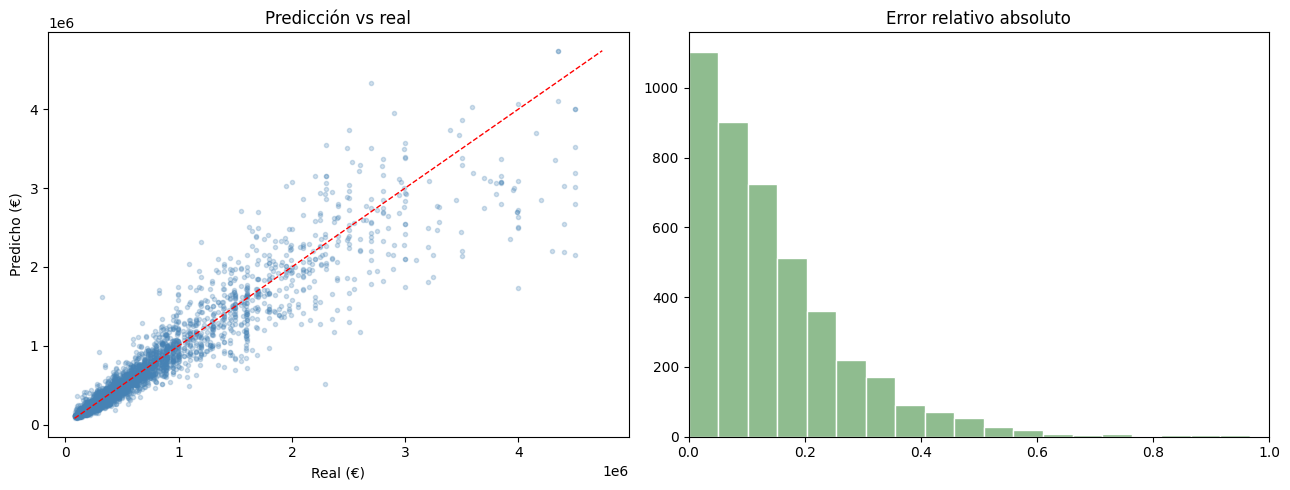

In [7]:

worst_neighborhoods = residuals.groupby('subtitle').agg(
    n=('real', 'size'),
    median_price=('real', 'median'),
    mae=('abs_error', 'mean'),
    mdape=('pct_error', 'median'),
    within_20=('pct_error', lambda s: (s <= 0.20).mean()),
    p90_abs_error=('abs_error', lambda s: s.quantile(0.90)),
    bias=('bias', 'mean'),
).query('n >= 20').sort_values('mae', ascending=False).head(25).round(4)
display(worst_neighborhoods)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(residuals['real'], residuals['pred'], s=9, alpha=0.25, color='steelblue')
lims = [min(residuals['real'].min(), residuals['pred'].min()), max(residuals['real'].max(), residuals['pred'].max())]
axes[0].plot(lims, lims, 'r--', linewidth=1)
axes[0].set_title('Predicción vs real')
axes[0].set_xlabel('Real (€)')
axes[0].set_ylabel('Predicho (€)')
axes[1].hist(residuals['pct_error'], bins=80, color='darkseagreen', edgecolor='white')
axes[1].set_xlim(0, 1)
axes[1].set_title('Error relativo absoluto')
plt.tight_layout()
plt.show()


,importance
sq_mt_built,30.3860
subtitle,29.6817
n_bathrooms,11.3923
has_lift,4.5386
floor,4.0766
house_type_id,4.0306
built_year,3.5297
n_rooms,2.6262
has_parking,1.8629
sq_mt_useful,1.6880


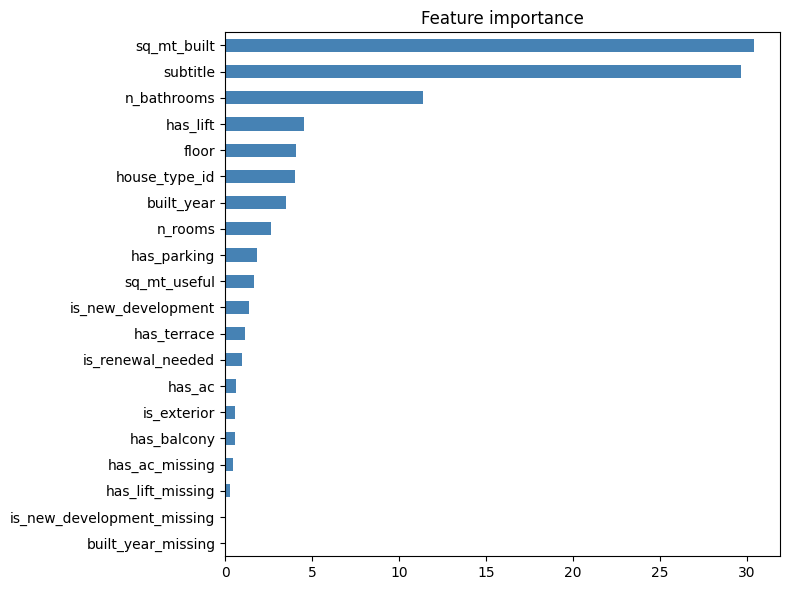

In [8]:

if MODELO_GANADOR == 'CatBoost':
    importance = pd.Series(model_core.get_feature_importance(), index=X.columns).sort_values(ascending=False)
else:
    encoded_names = list(NUM_FEATURES) + list(CAT_FEATURES)
    importance = pd.Series(getattr(fitted_model_for_importance, 'feature_importances_', np.zeros(len(encoded_names))), index=encoded_names).sort_values(ascending=False)

display(importance.head(25).to_frame('importance'))
importance.head(20).sort_values().plot(kind='barh', figsize=(8, 6), color='steelblue', title='Feature importance')
plt.tight_layout()
plt.show()


## 5. Gate de producción

In [9]:

def production_gate(metrics):
    test = metrics['test']
    checks = {
        'r2_at_least_0_90': test['R2'] >= 0.90,
        'median_ape_at_most_0_12': test['MdAPE'] <= 0.12,
        'within_20_pct_at_least_0_70': test['<=20%'] >= 0.70,
        'p95_abs_error_at_most_400k': test['AE_p95'] <= 400_000,
    }
    return {
        'approved_for_exact_price_production': bool(all(checks.values())),
        'approved_for_guidance_range_beta': bool(test['R2'] >= 0.88 and test['<=30%'] >= 0.80),
        'checks': checks,
    }

gate = production_gate(metrics)
print(json.dumps(gate, indent=2, ensure_ascii=False))


{
  "approved_for_exact_price_production": false,
  "approved_for_guidance_range_beta": true,
  "checks": {
    "r2_at_least_0_90": false,
    "median_ape_at_most_0_12": true,
    "within_20_pct_at_least_0_70": true,
    "p95_abs_error_at_most_400k": false
  }
}


## 6. Exportar artefactos

In [10]:

import sys
import joblib
sys.path.insert(0, str(ROOT / 'model'))
from training_utils import PricePredictionModel

wrapper = PricePredictionModel(
    model=model_core,
    residual_log_quantiles=residual_log_quantiles,
    features=list(X.columns),
    cat_features=CAT_FEATURES,
    target_transform='log1p',
)

if MODELO_GANADOR == 'CatBoost':
    model_core.save_model(ARTIFACTS_DIR / 'model.cbm')
else:
    # Se deja model.cbm anterior intacto solo si el ganador no es CatBoost.
    pass

joblib.dump(wrapper, ARTIFACTS_DIR / 'model.pkl')

feature_meta = {
    'features': list(X.columns),
    'base_features': BASE_FEATURES,
    'cat_features': CAT_FEATURES,
    'bool_features': BOOL_FEATURES,
    'missing_flag_features': [f'{col}_missing' for col in MISSING_FLAG_FEATURES],
    'target': TARGET,
    'target_transform': 'log1p',
    'model': MODELO_GANADOR,
    'best_params': best_params,
    'metrics': metrics['test'],
    'prediction_interval': {
        'method': 'validation_log_residual_quantiles',
        'residual_log_quantiles': residual_log_quantiles,
    },
    'production_gate': gate,
    'data': data_meta,
}
with open(ARTIFACTS_DIR / 'feature_columns.json', 'w', encoding='utf-8') as f:
    json.dump(feature_meta, f, ensure_ascii=False, indent=2)

neighborhoods = sorted(X['subtitle'].dropna().unique().tolist())
with open(ARTIFACTS_DIR / 'neighborhoods.json', 'w', encoding='utf-8') as f:
    json.dump(neighborhoods, f, ensure_ascii=False, indent=2)

metrics_report = {
    'data': data_meta,
    'splits': {'train': len(X_train), 'validation': len(X_val), 'test': len(X_test)},
    'metrics': metrics,
    'segments': {
        'by_price_band': by_price_band.reset_index().to_dict(orient='records'),
        'worst_neighborhoods_by_mae_min_20': worst_neighborhoods.reset_index().to_dict(orient='records'),
    },
    'feature_importance': importance.round(4).to_dict(),
    'production_gate': gate,
}
with open(ARTIFACTS_DIR / 'metrics_report.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_report, f, ensure_ascii=False, indent=2)

print('Artefactos exportados en:', ARTIFACTS_DIR)
for p in sorted(ARTIFACTS_DIR.iterdir()):
    print('-', p.name, f'{p.stat().st_size / 1024:.1f} KB')


Artefactos exportados en: /Users/danielfreites/Desktop/Proyectos IV/model/artifacts
- feature_columns.json 3.2 KB
- metrics_report.json 10.7 KB
- model.cbm 18277.0 KB
- model.pkl 18293.7 KB
- model_selection_summary.json 3.6 KB
- neighborhoods.json 2.6 KB
